# Emotion Analysis


In [ ]:
!pip install tweet-preprocessor 2>/dev/null 1>/dev/null
!pip install emoji
!pip install np_utils
!pip install hazm
!pip install plotly
! pip install --upgrade tensorflow==2.15

  Using cached tensorflow-2.15.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached ml_dtypes-0.2.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached wrapt-1.14.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached tensorflow_estimator-2.15.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [ ]:
import preprocessor as p
import numpy as np
import pandas as pd
from hazm import *
import emoji
import keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, GRU,SimpleRNN
from keras.layers import Dense, Activation, Dropout
from keras.layers import Embedding
from keras.layers import BatchNormalization
import np_utils
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing import text
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
import plotly.graph_objects as go
import plotly.express as px
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
# from kaggle_datasets import KaggleDatasets
import transformers
from transformers import TFAutoModel, AutoTokenizer
from tqdm.notebook import tqdm
from tqdm import tqdm

In [ ]:
print(tf.__version__)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
DATAPATH = "Dataset"

Mounted at /content/drive


# Data preparation  <a class="anchor" id="toc"></a>


In [ ]:
data = pd.read_csv(DATAPATH + "./train.tsv", sep='\t',names=["text", "feeling"])
test_data = pd.read_csv(DATAPATH + "./test.tsv", sep='\t',names=["text", "feeling"])
df_merged = pd.concat([data, test_data], ignore_index=True, sort=False)
data, test_data = train_test_split(df_merged, test_size=0.2)

In [ ]:
data = data[data["feeling"]!="OTHER"]
test_data = test_data[test_data["feeling"]!="OTHER"]

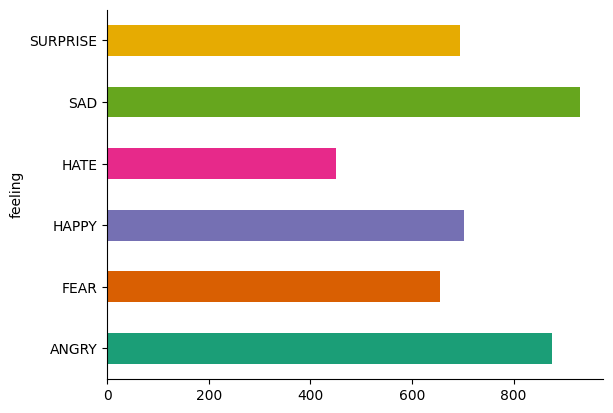

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
test_data

,text,feeling
7250,خشونت زخمی می کند و می شکند؛ التیام هم ندارد.....,SAD
1961,بحران #٣٠سالگي براي من فقط بحران مالي بود ، كه...,SAD
4196,چقدر خشنی تو آخه پسر چشم حسودت کور,SURPRISE
1506,رفتم آرایشگاه موهامو کوتاه کردم. به خانومه گفت...,SAD
4313,اتفاقا خیلی ترسوام,FEAR
...,...,...
5883,از آلبالو و مربای آلبالو و آلبالوپلو متنفرررررم,HATE
6000,خارشونو سگ گایید. مملکتم دقیقا همینجوری قسمت م...,ANGRY
6856,پاسخ شایسته علی انصاریان بازیکن سابق فوتبال به...,HAPPY
2313,این رزمایش سداد رید به اعصابم. یعنی یه ذره امی...,ANGRY


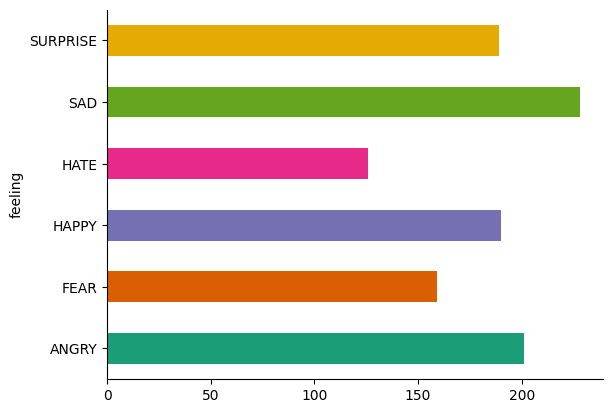

In [ ]:
# @title feeling

from matplotlib import pyplot as plt
import seaborn as sns
test_data.groupby('feeling').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

### Stop words

In [ ]:
def read_stopwords(file_path):
    with open(file=file_path, mode='r',encoding='utf-8', errors='ignore') as file:
        stopwords = file.readlines()
    stopwords = [word.strip() for word in stopwords]
    return stopwords

def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    filtered_text = ' '.join(filtered_words)
    return filtered_text

stopwords = read_stopwords(DATAPATH + 'stop-words.txt')
tqdm.pandas()
data['text'] = data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))
test_data['text'] = test_data['text'].progress_apply(lambda x: remove_stopwords(x, stopwords))

### Deemojize

In [ ]:
import demojize

tqdm.pandas()
data.text = data.text.progress_apply(lambda x : demojize.demojizePersian(x))

ModuleNotFoundError: No module named 'demojize'

In [ ]:
data

,text,feeling
4942,چرا آخه؟,SURPRISE
1244,کاش بفهمید با هر استوری ای ک از تبریک تولد گفت...,ANGRY
5824,صحنه منزجر کننده ایه جدی,HATE
4410,چرا واقعاً,SURPRISE
3913,کسی کوفتم واسه من نمیفرسته,ANGRY
...,...,...
467,سال خیلی عجیب و خوبی بود. خیلی اتفاقا هم افتاد...,SURPRISE
1250,#کارنامه۳۸ساله فقط تلاش جوون و دانشجو نخبه برا...,SAD
340,با چشماش چی داره میگه؟ حرومزاده ها خودتون میخا...,ANGRY
2941,تیمم و تیمم و تیمم و تیمم... این بود تیمت؟ ک.....,ANGRY


### Remove URLS and mentions <a class="anchor" id="dp-r"></a>
<a href="#toc">Back to the table of contents</a>

In [ ]:
import re

def punctuation(val):

    punctuations = '''()-[]{};:'"\,<>./@#$%^&_~'''

    for x in val.lower():
        x.replace("@username", " ")
        x.replace("username", " ")
        if x in punctuations:
            val = val.replace(x, " ")
    return val

def remove_emojis(text):
    # Emoji patterns (with variations)
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def clean_text(val):
    val = remove_emojis(val)
    val = punctuation(val)

    return val

In [ ]:
data["text_cleaned"]=data.text.apply(lambda x : clean_text(x))
test_data["text_cleaned"]=test_data.text.apply(lambda x : clean_text(x))
test_data

,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی میخواد تموم بشه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم ...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشون
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوبه من دومیشو میخوام سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتیه این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمیترسم ممنون اسپرسوی عزیز


In [ ]:
import re
def remove_english_words(text):
    english_pattern = re.compile(r'\b[a-zA-Z]+\b')
    return re.sub(english_pattern, '', text)

data["text_cleaned"]=data.text_cleaned.apply(lambda x : remove_english_words(x))
test_data["text_cleaned"]=test_data.text_cleaned.apply(lambda x : remove_english_words(x))
test_data


,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی میخواد تموم بشه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم ...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشون
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوبه من دومیشو میخوام سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتیه این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمیترسم ممنون اسپرسوی عزیز


In [ ]:

from multiprocessing import Pool, cpu_count
normalizer = Normalizer()
informal_normalizer = InformalNormalizer()
def normalizing(text):
    text = normalizer.normalize(text)
    text = text.replace(',', " ")
    temp_formal = informal_normalizer.normalize(text)
    #print(temp_formal)
    text = ""
    for sentence in temp_formal:
        temp_sent = ""
        for word in sentence:
            if len(word)>1:
                temp_sent += str(word[1])+ " "
            else:
                temp_sent += str(word[0])+ " "
        #print(f"\t-------> {temp_sent}")
        text += temp_sent + " "
    #print(text)
    #print(temp_formal)
    return text

def apply_parallel(df, func):
    num_partitions = cpu_count()  # Number of partitions to split the DataFrame
    num_cores = cpu_count()  # Number of cores to use
    print(num_cores)
    # Split the DataFrame into partitions
    df_split = np.array_split(df, num_partitions)

    # Create a pool of workers
    pool = Pool(num_cores)

    # Apply the function to each partition in parallel
    df = pd.concat(pool.map(func, df_split))

    # Close the pool of workers
    pool.close()
    pool.join()

    return df

# Define the function to be applied to each partition of the DataFrame
def parallel_apply(df):
    return df.progress_apply(normalizing)

# Call the function in parallel
data['text_cleaned'] = apply_parallel(data['text_cleaned'], parallel_apply)
data.to_csv("normalized_formal_data.csv")

test_data['text_cleaned'] = apply_parallel(test_data['text_cleaned'], parallel_apply)
data.to_csv("normalized_formal__test_data.csv")



12


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
100%|██████████| 361/361 [00:00<00:00, 383.76it/s]

100%|██████████| 361/361 [00:00<00:00, 367.74it/s]


100%|██████████| 361/361 [00:00<00:00, 363.50it/s]


12


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
100%|██████████| 89/89 [00:00<00:00, 373.00it/s]

100%|██████████| 89/89 [00:00<00:00, 384.48it/s]

100%|██████████| 89/89 [00:00<00:00, 350.04it/s]

100%|██████████| 89/89 [00:00<00:00, 315.40it/s]


In [ ]:
# clean_text("isn't 💡 adultry @ttt good bad ... ! ? ")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


### Remove empty comments <a class="anchor" id="dp-re"></a>
<a href="#toc">Back to the table of contents</a>

In [ ]:
data = data[data.text_cleaned != ""]
test_data = test_data[test_data.text_cleaned != ""]
test_data

,text,feeling,text_cleaned
4612,کی میخواد تموم بشه,SAD,کی می‌خواهد تمام بشوه
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدم خوشگلوخوشاخلاق رو همه دوست دارند ؛ تو اگه ...
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم حت...
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...
4190,والله با این نوناشون,ANGRY,والله با این نوناشان
...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوب است من دومیش و می‌خواهم سفارش بدم
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتی است این حساسیت بهاری
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمی‌ترسم ممنون اسپرسوی عزیز


# Modeling  <a class="anchor" id="m"></a>

### Encoding the data and train test split <a class="anchor" id="m-ed"></a>

In [ ]:
sent_to_id = {"ANGRY":0, "FEAR":1, "HAPPY":2, "HATE":3, "SAD":4, "SURPRISE":5, "OTHER":6}

In [ ]:
selected_columns = ['Anger', 'Fear', 'Happiness', 'Hatred', 'Sadness', 'Wonder', 'Other']
selected_data = data[selected_columns]
data['mean'] = selected_data.mean(axis=1)
normalized_data = data[data['mean'] > 0.5]
std_devs = np.std(selected_data, axis=1)
def create_bitstring(row):
    bitstring = ''.join(['1' if val >= 2 else '0' for val in row])
    return bitstring

normalized_data['bitstring'] = selected_data.apply(lambda row: create_bitstring(row), axis=1)
# Get the maximum values for each row and the corresponding column names
results = []
for i in range(len(normalized_data["mean"])):
    # Find the index of the maximum value in the row
    max_index = selected_data.iloc[i].idxmax()
    results.append(max_index)
normalized_data['sentiment'] = results

data["feeling_id"] = data['feeling'].map(sent_to_id)
test_data["feeling_id"] = test_data['feeling'].map(sent_to_id)
data.shape

(4336, 4)

In [ ]:

weights = {
    ('Anger', 'Hatred'): {'Anger': 0.4, 'Hatred': 0.6},
    ('Happiness', 'Wonder'): {'Happiness': 0.4, 'Wonder': 0.6}
}

# Define a function to get the highest emotion based on the rules
def get_highest_emotion(row):
    max_value = row[['Anger', 'Fear', 'Happiness', 'Hatred', 'Sadness', 'Wonder']].max()
    candidates = row[row == max_value].index.tolist()

    # Check if there's a tie
    if len(candidates) > 1:
        # Check if candidates are in the weighted pairs
        for pair, weight in weights.items():
            if set(pair).issubset(candidates):
                # Select based on the weighted values
                scores = {emotion: row[emotion] * weight[emotion] for emotion in pair}
                return sent_to_id[max(scores, key=scores.get)]
        # If not a special pair, pick randomly
        return sent_to_id[np.random.choice(candidates)]
    else:
        # No tie, return the single highest emotion
        return sent_to_id[candidates[0]]

# Apply the function to each row
normalized_data['Highest_Emotion'] = normalized_data[selected_columns].apply(get_highest_emotion, axis=1)

# Display the result
(normalized_data[['text', 'Highest_Emotion']])


In [ ]:
# data.to_csv("cleaned_dataset.csv")
test_data

,text,feeling,text_cleaned,feeling_id
4612,کی میخواد تموم بشه,SAD,کی می‌خواهد تمام بشوه,4
2948,آدمِ خوشگلوخوشاخلاق ر همه دوست دارن؛ تو اگه زر...,HAPPY,آدم خوشگلوخوشاخلاق رو همه دوست دارند ؛ تو اگه ...,2
527,تنفر از بقیه هم ریشهاش تنفر از خوده. برای هم ...,HATE,تنفر از بقیه هم ریشهاش تنفر از خوده برای هم حت...,3
3784,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,HAPPY,مرسی عزیز و همچنین برای شما بهترین آرزوها می‌ک...,2
4190,والله با این نوناشون,ANGRY,والله با این نوناشان,0
...,...,...,...,...
3463,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,ANGRY,یعنی پفیوز اعظم فقط خودم پونزده روز فرجه داشتم...,0
7265,خیلی خوبه من دومیشو میخوام سفارش بدم,HAPPY,خیلی خوب است من دومیش و می‌خواهم سفارش بدم,2
4948,خیلی کوفتیه این حساسیت بهاری,ANGRY,خیلی کوفتی است این حساسیت بهاری,0
5490,دو سه ساله نمیترسم ممنون اسپرسوی عزیز,HAPPY,دو سه ساله نمی‌ترسم ممنون اسپرسوی عزیز,2


In [ ]:
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(data.feeling_id)

onehot_encoder = OneHotEncoder(sparse_output=False)

integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# Y = normalized_data.bitstring.apply(lambda x: int(x, 2))
Y = onehot_encoder.fit_transform(integer_encoded)


In [ ]:
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(test_data.feeling_id)

onehot_encoder = OneHotEncoder(sparse_output=False)

integer_encoded = integer_encoded.reshape(len(integer_encoded), 1)
# Y = normalized_data.bitstring.apply(lambda x: int(x, 2))
test_Y = onehot_encoder.fit_transform(integer_encoded)


In [ ]:
X_train = data.text_cleaned
X_test = test_data.text_cleaned
y_train = Y
y_test = test_Y
X_train.shape


(4336,)

### LSTM <a class="anchor" id="m-l"></a>

In [ ]:
# using keras tokenizer here
token = text.Tokenizer(num_words=None)
max_len = 160
Epoch = 5
token.fit_on_texts(list(X_train) + list(X_test))
X_train_pad = sequence.pad_sequences(token.texts_to_sequences(X_train), maxlen=max_len)
X_test_pad = sequence.pad_sequences(token.texts_to_sequences(X_test), maxlen=max_len)

In [ ]:
w_idx = token.word_index

In [ ]:
embed_dim = 160
lstm_out = 250

model = Sequential()
model.add(Embedding(len(w_idx) +1, embed_dim,input_length = X_test_pad.shape[1]))
model.add(LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2))
model.add(Dropout(0.2))
model.add(keras.layers.Dense(10, activation='relu'))
model.add(Dropout(0.2))
model.add(keras.layers.Dense(6, activation='softmax'))
#adam rmsprop
model.compile(loss = "categorical_crossentropy", optimizer='adam',metrics = ['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 160, 160)          3086080   
                                                                 
 lstm (LSTM)                 (None, 250)               411000    
                                                                 
 dropout (Dropout)           (None, 250)               0         
                                                                 
 dense (Dense)               (None, 10)                2510      
                                                                 
 dropout_1 (Dropout)         (None, 10)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                 66        
                                                                 
Total params: 3499656 (13.35 MB)
Trainable params: 34996

In [ ]:
batch_size = 32

In [ ]:
history = model.fit(X_train_pad, y_train, epochs = Epoch, batch_size=batch_size,validation_data=(X_test_pad, y_test))

Epoch 1/5
 52/136 [==========>...................] - ETA: 45s - loss: 1.7759 - accuracy: 0.2133

KeyboardInterrupt: 

In [ ]:
model.save('./models/feelingModel-5.h5')

In [ ]:
def get_sentiment(model,text):
    text = clean_text(text)
    #tokenize
    # stopwords = read_stopwords('stop-words.txt')
    # text = remove_stopwords(text,stopwords)
    normalizer = Normalizer()
    text = normalizer.normalize(text)
    temp_formal = informal_normalizer.normalize(text)
    text = ""
    for sentence in temp_formal:
        temp_sent = ""
        for word in sentence:
            if len(word)>1:
                temp_sent += str(word[1])+ " "
            else:
                temp_sent += str(word[0])+ " "
        #print(f"\t-------> {temp_sent}")
        text += temp_sent + " "
    print(text)
    twt = token.texts_to_sequences([text])
    twt = sequence.pad_sequences(twt, maxlen=max_len, dtype='int32')
    sentiment = model.predict(twt,batch_size=1,verbose = 2)
    sent = np.round(np.dot(sentiment,100).tolist(),0)[0]
    result = pd.DataFrame([sent_to_id.keys(),sent]).T
    result.columns = ["sentiment","percentage"]
    result=result[result.percentage !=0]
    return result

In [ ]:
def plot_result(df):
    #colors=['#D50000','#000000','#008EF8','#F5B27B','#EDECEC','#D84A09','#019BBD','#FFD000','#7800A0','#098F45','#807C7C','#85DDE9','#F55E10']
    #fig = go.Figure(data=[go.Pie(labels=df.sentiment,values=df.percentage, hole=.3,textinfo='percent',hoverinfo='percent+label',marker=dict(colors=colors, line=dict(color='#000000', width=2)))])
    #fig.show()
    colors={'SURPRISE':'rgb(20,80,30)','HATE':'rgb(0,0,0)',
                     'SAD':'rgb(0,142,248)','HAPPY':'rgb(245,178,123)',
                     'FEAR':'rgb(217,216,216)','ANGRY':'rgb(216,54,5)','OTHER':'rgb(200,56,256)'}
    col_2={}
    for i in df.sentiment.to_list():
        i = str(i)
        col_2[i]=colors[i]
    fig = px.pie(df, values='percentage', names='sentiment',color='sentiment',color_discrete_map=col_2,hole=0.3)
    fig.show()

### Test LSTM Results <a class="anchor" id="m-lr"></a>

In [ ]:
from tensorflow.keras.models import load_model
# model = load_model('feelingModel.h5')
result =get_sentiment(model," معلوم نیست کی اسرائیل موشک بزنه رو سرمون")
print(result)
plot_result(result)
result =get_sentiment(model," از دیروز دارم گریه میکنم")
print(result)
plot_result(result)
result =get_sentiment(model," خیلی خوش میگذره ")
print(result)
plot_result(result)

معلوم نیست کی اسرائیل موشک بزنه رو سرمان  
1/1 - 0s - 258ms/step
  sentiment percentage
0     ANGRY        3.0
1      FEAR       26.0
2     HAPPY       16.0
3      HATE       14.0
4       SAD        1.0
5  SURPRISE       41.0
6     OTHER       None


از دیروز دارم گریه می‌کنم  
1/1 - 0s - 67ms/step
  sentiment percentage
0     ANGRY        3.0
1      FEAR       14.0
2     HAPPY       61.0
3      HATE       11.0
4       SAD        8.0
5  SURPRISE        4.0
6     OTHER       None


خیلی خوش می‌گذره  
1/1 - 0s - 73ms/step
  sentiment percentage
0     ANGRY        2.0
1      FEAR        2.0
2     HAPPY       90.0
3      HATE        5.0
4       SAD        2.0
6     OTHER       None


## Creating a Dataframe of Loss And Accuracy.

In [ ]:
model_loss = pd.DataFrame(history.history)
model_loss.head()


,accuracy,loss,val_accuracy,val_loss
0,0.290808,1.654198,0.405355,1.482932
1,0.555684,1.170543,0.546630,1.275581
2,0.738828,0.733034,0.565097,1.399462
3,0.829127,0.488181,0.566020,1.632424
4,0.881686,0.320625,0.582641,1.812001


## Lets visualize the Loss over the Epochs.

<Axes: >

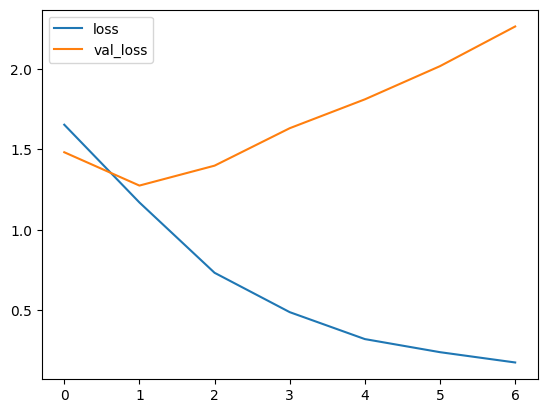

In [ ]:
import uuid

id = uuid.uuid1().hex
model_path = f'./models/{id}_lstm_model_digikala.h5'

model_loss[['loss','val_loss']].plot()
# plt.savefig(f'./plots/{id}_loss.png')
# plt.show()

## Lets visualize the Accuracy over the Epochs.

<Axes: >

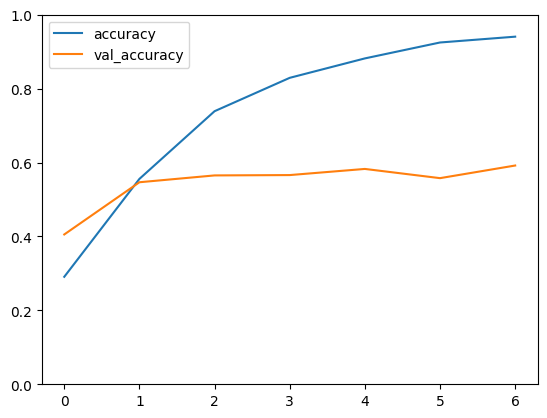

In [ ]:
model_loss[['accuracy','val_accuracy']].plot(ylim=[0,1])
# plt.savefig(f'./plots/{id}_accuracy.png')
# plt.show()

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range=range(len(acc))
plt.plot(epochs_range,acc,label='Trainin_acc',color='blue')
plt.plot(epochs_range,val_acc,label='Validation_acc',color='red')
plt.legend()
plt.title("Training and Validation Accuracy")

KeyError: 'acc'

In [ ]:
plt.plot(epochs_range,loss,label='Training_loss',color='blue')
plt.plot(epochs_range,val_loss,label='Validation_loss',color='red')
plt.legend()
plt.title("Training and Validation loss")

NameError: name 'plt' is not defined

In [ ]:
predict_x = model.predict(X_test_pad)

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step


In [ ]:
from sklearn.metrics import mean_squared_error

y_test = np.argmax(y_test,axis=1)
print(y_test)
y_pred=np.argmax(predict_x,axis=1)
print(y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
MeanSquaredError = mse


[4 1 3 ... 3 3 2]
[4 4 3 ... 3 4 4]
Mean Squared Error: 3.520775623268698


In [ ]:
import matplotlib.pyplot as plt
plt.plot(y_val, label='Actual')
plt.plot(predicted, label='Predicted')
plt.legend()
plt.show()
y_val.shape

NameError: name 'y_val' is not defined

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_val)), y_val+0.008, color='blue', label='Actual', alpha=0.5)
plt.scatter(range(len(predicted)), predicted, color='orange', label='Predicted', alpha=0.5)
plt.xlabel('Data Point Index')
plt.ylabel('Class Label')
plt.title('Comparison of Actual and Predicted Labels')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from datetime import datetime
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")
model.save(model_path)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Example true labels and predicted labels
true_labels = y_test
predicted_labels = y_pred

# Calculate precision
precision = precision_score(true_labels, predicted_labels, average="macro")

# Calculate recall
recall = recall_score(true_labels, predicted_labels,average="macro")

# Calculate F-score
f_score = f1_score(true_labels, predicted_labels,average="macro")

print("Precision:", precision)
print("Recall:", recall)
print("F-score:", f_score)
print("Accuracy_score: ", accuracy_score(true_labels, predicted_labels))
y_train.shape


Precision: 0.6053864746263009
Recall: 0.5908691343187609
F-score: 0.5948437366852436
Accuracy_score:  0.5918744228993537


(4319, 6)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    # print(im)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

class_names = np.array(["ANGRY", "FEAR", "HAPPY", "HATE", "SAD", "SURPRISE", "OTHER"])
np.set_printoptions(precision=2)
# plot_confusion_matrix(true_labels, predicted_labels, classes=class_names, normalize=True)


In [ ]:
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# Append to text file
with open("metrics_digikala.txt", "a") as file:
    file.write(f"\n{current_date} | Precision: {precision} | Recall: {recall} | F-score: {f_score}\n")

print("Metrics appended to file.")

In [ ]:
import csv

# Append to CSV file
with open("metrics_digikala.csv", "a", newline="") as file:
    writer = csv.writer(file)
    # If the file is empty, write the header
    if file.tell() == 0:
        writer.writerow(["Id","Date", "Model Path","Embedding", "epochs", "batch_size","normalization","vector dimentions","train-test split",
                         "MeanSquaredError", "Precision", "Recall", "F-score"])
    writer.writerow([id, current_date, model_path, embedding, epochs, batch_size, normalization, vector_size, train_test, MeanSquaredError, precision, recall, f_score])

print("Metrics appended to CSV file.")

In [ ]:
! notify-send "Training done"

In [ ]:
test_sent = "کیفیت دوربین خیلی پایینه."
tokenizer = WordTokenizer(join_verb_parts=False, replace_links=True)
words=[word.lower() for word in tokenizer.tokenize(test_sent)]

MAX_LEN=10
tokenizer_obj=Tokenizer()
tokenizer_obj.fit_on_texts([words])
sequences=tokenizer_obj.texts_to_sequences([words])

tweet_pad=pad_sequences(sequences,maxlen=MAX_LEN,truncating='post',padding='post')

result = model.predict(tweet_pad)
# result = (result[0]>=0.5).astype(int)
print(tweet_pad)
result



NameError: name 'Tokenizer' is not defined

### BERT Model


In [ ]:

from transformers import BertConfig, BertTokenizer
from transformers import TFBertModel, TFBertForSequenceClassification
from transformers import glue_convert_examples_to_features

import tensorflow as tf

In [ ]:
MAX_LEN = 128
TRAIN_BATCH_SIZE = 16
VALID_BATCH_SIZE = 16
TEST_BATCH_SIZE = 16

EPOCHS = 3
EEVERY_EPOCH = 1000
LEARNING_RATE = 2e-5
CLIP = 0.0

MODEL_NAME_OR_PATH = 'HooshvareLab/bert-fa-base-uncased'
OUTPUT_PATH = '/bert/bert_model.bin'

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

In [ ]:
labels = list(sorted(data['feeling'].unique()))
label2id = {label: i for i, label in enumerate(labels)}
id2label = {v: k for k, v in label2id.items()}

print(f'label2id: {label2id}')
print(f'id2label: {id2label}')

label2id: {'ANGRY': 0, 'FEAR': 1, 'HAPPY': 2, 'HATE': 3, 'SAD': 4, 'SURPRISE': 5}
id2label: {0: 'ANGRY', 1: 'FEAR', 2: 'HAPPY', 3: 'HATE', 4: 'SAD', 5: 'SURPRISE'}


In [ ]:

# setup the tokenizer and configuration

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME_OR_PATH)
config = BertConfig.from_pretrained(
    MODEL_NAME_OR_PATH, **{
        'label2id': label2id,
        'id2label': id2label,
    })

print(config.to_json_string())

NameError: name 'BertTokenizer' is not defined

In [ ]:
idx = np.random.randint(0, len(data))
sample_comment = data.iloc[idx]['text']
sample_label = data.iloc[idx]['feeling']

print(f'Sample: \n{sample_comment}\n{sample_label}')

Sample: 
والا . مردک روانی
ANGRY


In [ ]:
tokens = tokenizer.tokenize(sample_comment)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f'  Comment: {sample_comment}')
print(f'   Tokens: {tokenizer.convert_tokens_to_string(tokens)}')
print(f'Token IDs: {token_ids}')

  Comment: والا . مردک روانی
   Tokens: والا . مردک روانی
Token IDs: [20077, 1012, 93958, 6433]


In [ ]:

encoding = tokenizer.encode_plus(
    sample_comment,
    max_length=32,
    truncation=True,
    add_special_tokens=True, # Add '[CLS]' and '[SEP]'
    return_token_type_ids=True,
    return_attention_mask=True,
    padding='max_length',
    return_tensors='pt',  # Return PyTorch tensors
)

print(f'Keys: {encoding.keys()}\n')
for k in encoding.keys():
    print(f'{k}:\n{encoding[k]}')

Keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

input_ids:
tensor([[    2,  9808,  2789,  1003,  7752,     1,  3834,  1001,  3767,  7793,
          5453,  5913,  1012,  2789, 19265,  7319,  5929,  3559,  4617,  1012,
         23489,  7287,  3380,  1379,  4078, 50233, 15888,  1012,  2789,  3810,
          2820,     4]])
token_type_ids:
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]])


In [ ]:
class InputExample:
    """ A single example for simple sequence classification. """

    def __init__(self, guid, text_a, text_b=None, label=None):
        """ Constructs a InputExample. """
        self.guid = guid
        self.text_a = text_a
        self.text_b = text_b
        self.label = label


def make_examples(tokenizer, x, y=None, maxlen=128, output_mode="classification", is_tf_dataset=True):
    examples = []
    y = y if isinstance(y, list) or isinstance(y, np.ndarray) else [None] * len(x)

    for i, (_x, _y) in tqdm(enumerate(zip(x, y)), position=0, total=len(x)):
        guid = "%s" % i
        label = int(_y)

        if isinstance(_x, str):
            text_a = _x
            text_b = None
        else:
            assert len(_x) == 2
            text_a = _x[0]
            text_b = _x[1]

        examples.append(InputExample(guid=guid, text_a=text_a, text_b=text_b, label=label))

    features = glue_convert_examples_to_features(
        examples,
        tokenizer,
        maxlen,
        output_mode=output_mode,
        label_list=list(np.unique(y)))

    all_input_ids = []
    all_attention_masks = []
    all_token_type_ids = []
    all_labels = []

    for f in tqdm(features, position=0, total=len(examples)):
        if is_tf_dataset:
            all_input_ids.append(tf.constant(f.input_ids))
            all_attention_masks.append(tf.constant(f.attention_mask))
            all_token_type_ids.append(tf.constant(f.token_type_ids))
            all_labels.append(tf.constant(f.label))
        else:
            all_input_ids.append(f.input_ids)
            all_attention_masks.append(f.attention_mask)
            all_token_type_ids.append(f.token_type_ids)
            all_labels.append(f.label)

    if is_tf_dataset:
        dataset = tf.data.Dataset.from_tensor_slices(({
            'input_ids': all_input_ids,
            'attention_mask': all_attention_masks,
            'token_type_ids': all_token_type_ids
        }, all_labels))

        return dataset, features

    xdata = [np.array(all_input_ids), np.array(all_attention_masks), np.array(all_token_type_ids)]
    ydata = all_labels

    return [xdata, ydata], features


In [ ]:
x_train, y_train = data['text'].values.tolist(), data['feeling_id'].values.tolist()
x_valid, y_valid = test_data['text'].values.tolist(), test_data['feeling_id'].values.tolist()

In [ ]:
train_dataset_base, train_examples = make_examples(tokenizer, x_train, y_train, maxlen=128)
valid_dataset_base, valid_examples = make_examples(tokenizer, x_valid, y_valid, maxlen=128)

# test_dataset_base, test_examples = make_examples(tokenizer, x_test, y_test, maxlen=128)
# [xtest, ytest], test_examples = make_examples(tokenizer, x_test, y_test, maxlen=128, is_tf_dataset=False)

100%|██████████| 4336/4336 [00:00<00:00, 354395.27it/s]
/usr/local/lib/python3.10/dist-packages/transformers/data/processors/glue.py:66: FutureWarning: This function will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification/run_glue.py
  warnings.warn(DEPRECATION_WARNING.format("function"), FutureWarning)
100%|██████████| 1066/1066 [00:00<00:00, 11809.98it/s]


In [ ]:
def get_training_dataset(dataset, batch_size):
    dataset = dataset.repeat()
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(batch_size)

    return dataset

def get_validation_dataset(dataset, batch_size):
    dataset = dataset.batch(batch_size)

    return dataset

In [ ]:
train_dataset = get_training_dataset(train_dataset_base, TRAIN_BATCH_SIZE)
valid_dataset = get_training_dataset(valid_dataset_base, VALID_BATCH_SIZE)

train_steps = len(train_examples) // TRAIN_BATCH_SIZE
valid_steps = len(valid_examples) // VALID_BATCH_SIZE

train_steps, valid_steps


(271, 65)

In [ ]:
def build_model(model_name, config, learning_rate=3e-5):
    model = TFBertForSequenceClassification.from_pretrained(model_name, config=config)

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
    model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

    return model

In [ ]:
model = build_model(MODEL_NAME_OR_PATH, config, learning_rate=LEARNING_RATE)


All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
%%time

r = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    steps_per_epoch=train_steps,
    validation_steps=valid_steps,
    epochs=EPOCHS,
    verbose=1)

final_accuracy = r.history['val_accuracy']
print('FINAL ACCURACY MEAN: ', np.mean(final_accuracy))

Epoch 1/3
271/271 [==============================] - 112s 194ms/step - loss: 1.0620 - accuracy: 0.6176 - val_loss: 0.7857 - val_accuracy: 0.7490
Epoch 2/3
271/271 [==============================] - 36s 134ms/step - loss: 0.5249 - accuracy: 0.8316 - val_loss: 0.7372 - val_accuracy: 0.7548
Epoch 3/3
271/271 [==============================] - 35s 127ms/step - loss: 0.2801 - accuracy: 0.9170 - val_loss: 0.8462 - val_accuracy: 0.7356
FINAL ACCURACY MEAN:  0.7464743653933207
CPU times: user 2min 56s, sys: 7.9 s, total: 3min 4s
Wall time: 3min 2s


In [ ]:
# save the model

model.save_pretrained("./models/bert")
!zip -r ./models/bert_model.zip ./models/bert

  adding: models/bert/ (stored 0%)
  adding: models/bert/tf_model.h5 (deflated 8%)
  adding: models/bert/config.json (deflated 49%)
